# Consigna

Senoidal de frecuencia 
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>k</mi>
    <mn>0</mn>
  </msub>
  <mo>=</mo>
  <mo fence="false" stretchy="false">{</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.25</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo fence="false" stretchy="false">}</mo>
</math>
. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi mathvariant="normal">&#x394;</mi>
    <mi>f</mi>
  </msub>
</math>
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?



# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [224]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    '''power(x: np.ndarray) -> float:
        Returns the power of the signal x, defined as the mean of the square of the Voltage signal. 
    '''
    return np.mean(np.mean(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray | int, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: Number of points or signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    if type(xx) == int:
        nn = xx
    else:
        nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

def fft_shift(xx: np.ndarray) -> np.ndarray:
    '''fft_shift
    Shifts the fft of the signal xx, so that the zero frequency component is in the center of the spectrum. This is equivalent to np.fft.fftshift, but it also normalizes the fft by the length of the signal, so that the values are correct.
    '''
    N = xx.shape[0]
    return np.concatenate((xx[N//2:], xx[:N//2]))


# Respuesta

En ejercicios anteriores se demostro la FFT, cuales eran sus inconvenientes y cómo mejorar la misma con ventaneo y zero-padding.
Ahora se obtendran medidas de señales utilizando su espectro en frecuencia.

Se realizarán 2 mediciones: Valor pico de la senoidal (correspondiente a su energía) y su frecuencia. Ambos se estimarán a partir de datos de la FFT.
La energía se estimará como el valor de la senoidal en la muestra F0.
La frecuencia se estimará como el índice cuyo valor sea máximo en la FFT.

In [225]:
def check_est(xx, f0, fs, N):
    '''check_est(xx, f0, fs, N):
        Checks the estimation of the amplitude and frequency of a signal xx, given the true frequency f
        xx: signal to check the estimation of amplitude and frequency. It is expected to be a 2D array with shape (N, ...).
        f0: true frequency of the signal. It is expected to be a scalar.
        fs: sampling frequency of the signal. It is expected to be a scalar.
        N: number of points to calculate the fft. It is expected to be a scalar.
    '''
    N_real = xx.shape[0]
    xx_fft = np.fft.fft(xx, n=N, axis=0) / N_real
    xx_fft_abs = np.abs(xx_fft)

    a_estimado = 2 * xx_fft_abs[int(f0*N/fs), :]
    freq_estimado = np.argmax(xx_fft_abs[0:N//2, :], axis=0)*fs/N

    return xx_fft_abs, a_estimado, freq_estimado

## Prueba 1:

- Señal con 3dB de ruido, con una frecuencia variable uniforme de +-2 
- Se utilizan 4 ventanas distintas.
- Se calcula el sesgo y varianza de una estimación de energía/amplitud y de frecuencia.

In [226]:
from scipy import signal
####### VALORES 
N = 2000
fs = 2000
vmax = 2**.5
snr = 3
f0 = fs/4

cant_muestras = 200

####### VENTANAS 
windows = ["rectangular", "flattop", "blackman-harris", "hamming"]
win = {}
win[windows[0]] = np.ones(N).reshape(-1,1)
win[windows[1]] = signal.windows.flattop(N).reshape(-1,1)
win[windows[2]] = signal.windows.blackmanharris(N).reshape(-1,1)
win[windows[3]] = signal.windows.hamming(N).reshape(-1,1)

matrix_win = {}
for key in win.keys():
    win[key] = win[key]/np.mean(win[key])
    matrix_win[key] = np.tile(win[key], (1, cant_muestras))

####### SEÑAL
fr = np.random.uniform(-2,2, cant_muestras)
freq = fr + f0

xx = [mi_sen_ruidosa(vmax=vmax, ff=freq[i], nn=N, fs=fs, snr=snr)[0] for i in range(cant_muestras)]
xx = np.hstack(xx)

In [227]:
####### ESTIMADORES 
a_est = {}
freq_est = {}
xx_fft_abs = {}

for key in matrix_win.keys():
	xx_ventaneado = xx * matrix_win[key]
	xx_fft_abs[key], a_est[key], freq_est[key] = check_est(xx_ventaneado, f0, fs, N)

In [228]:
##### Cálculo de sesgo
sesgo_a = {}
sesgo_freq = {}
var_a = {}
var_freq = {}

for key in a_est.keys():
    sesgo_a[key] = np.mean(vmax - a_est[key])
    var_a[key] = np.var(vmax - a_est[key])
    sesgo_freq[key] = np.mean(freq - freq_est[key])
    var_freq[key] = np.var(freq - freq_est[key])


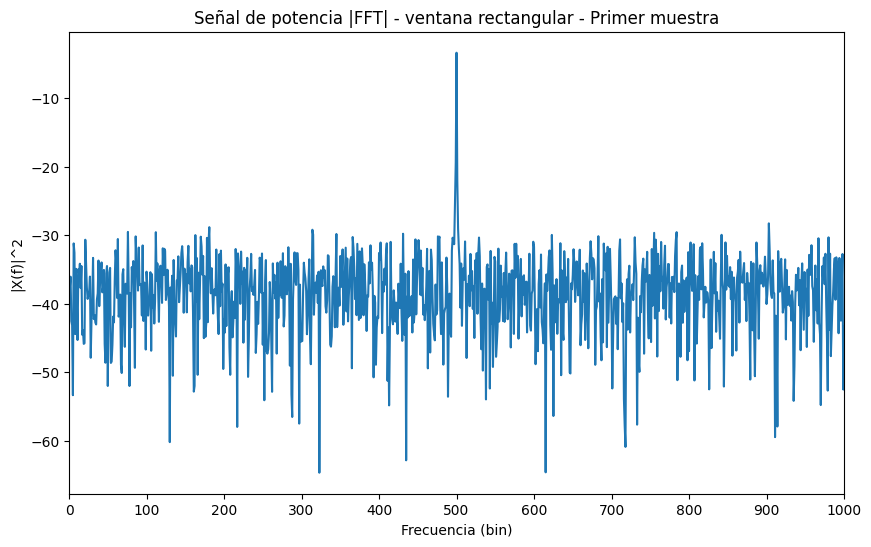

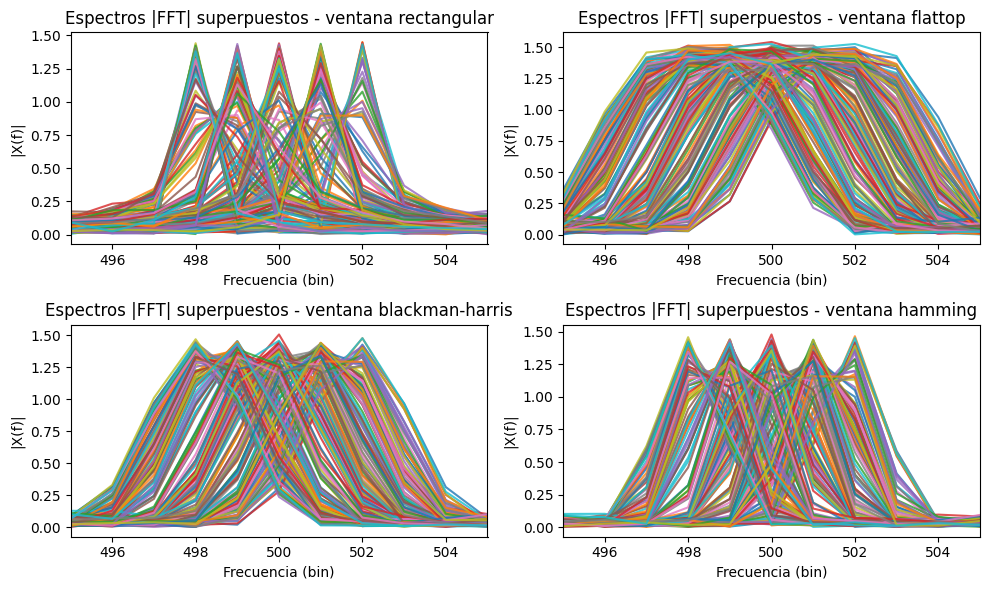

In [229]:
##### Check de primer muestra
PXX = xx_fft_abs["rectangular"][:,0]**2
plt.figure(figsize=(10,6))
plt.plot(10*np.log10(PXX))
plt.title("Señal de potencia |FFT| - ventana rectangular - Primer muestra")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|^2")
plt.xlim(0, N//2)
plt.xticks(np.arange(0, N//2+1, N/20))
plt.show()


##### Gráfico de espectros superpuestos
plt.figure(figsize=(10,6))
for key in xx_fft_abs.keys():
    plt.subplot(2,2,windows.index(key)+1)
    for i in range(xx_fft_abs[key].shape[1]):
        plt.plot(2*xx_fft_abs[key][:, i], alpha=0.8)
    plt.xlim(f0*0.99, f0*1.01)
    plt.title(f"Espectros |FFT| superpuestos - ventana {key}")
    plt.xlabel("Frecuencia (bin)")
    plt.ylabel("|X(f)|")
    plt.tight_layout()
plt.show()


Se presentan 2 gráficos. 

El primer gráfico simplemente muestra la FFT de potencia de la primer muestra que se obtuvo. Como se puede observar, es una delta en valor f0 con su piso de ruido correspondiente.

El segundo gráfico nos muestra una comparativa con todas las muestras realizadas, superpuestas, para cada una de las ventanas. Se logra observar el efecto de las ventanas y como estas expanden los lóbulos principales de la señal. En el caso de flattop, la mayoría de señales terminaron dejando un valor muy cercano entre ellas dentro de los límites de f0.

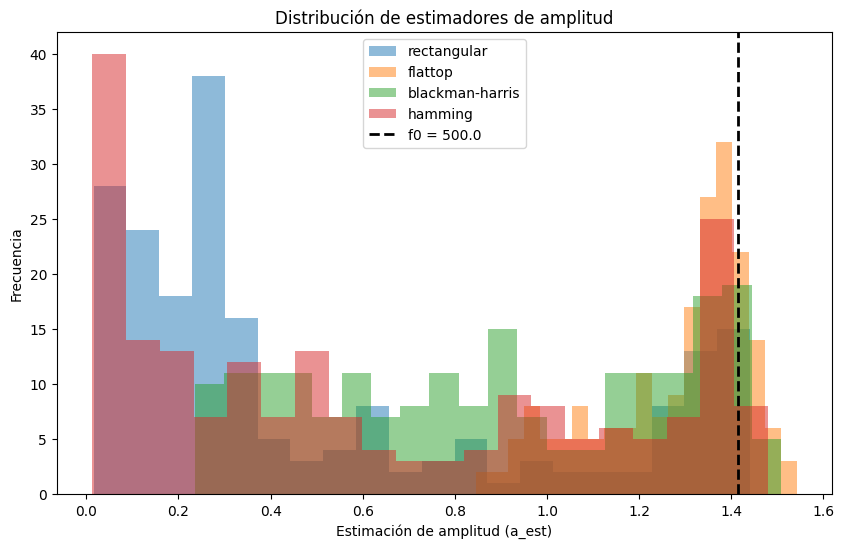

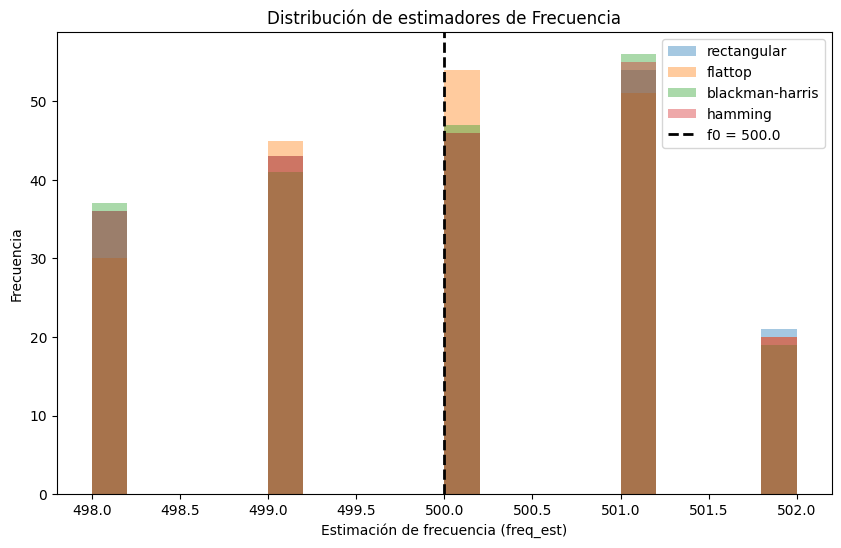


Ventana         |        Sesgo a      Varianza a      Sesgo freq   Varianza freq
rectangular     |          0.911           0.219        -0.00876          0.0776 
flattop         |          0.134          0.0264         -0.0338           0.138 
blackman-harris |          0.519           0.147         0.00124           0.078 
hamming         |          0.788           0.257        -0.00376          0.0776 


In [230]:
##### Histograma para cada ventana
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .5

for key in a_est.keys():
    ax.hist(a_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(vmax, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de amplitud (a_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de amplitud")
ax.legend()
plt.show()


##### Histograma para cada ventana
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .4
for key in freq_est.keys():
    ax.hist(freq_est[key], bins=bins, alpha=alpha, label=key)

ax.axvline(f0, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de frecuencia (freq_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de Frecuencia")

ax.legend()
plt.show()


print("\n" + "="*80)
print(f"{'Ventana':<15} |{'Sesgo a':>15} {'Varianza a':>15} {'Sesgo freq':>15} {'Varianza freq':>15}")
print("="*80)
for key in sesgo_a.keys():
    print(
        f"{key:<15} |"
        f"{sesgo_a[key]:>15.3g} "
        f"{var_a[key]:>15.3g} "
        f"{sesgo_freq[key]:>15.3g} "
        f"{var_freq[key]:>15.3g} "
    )
print("="*80)

Se realizaron los histogramas de nuestro estimador de frecuencia y de energía. 

En un inicio, la energía tenía añadido un ruido normal gaussiano y una primera aproximación era suponer que la salida iba a tener la misma distribución. Muy por el contrario, se observa que la distribución no se encuentra centrada con respecto al valor real y que encima varía mucho dependiendo de la ventana.

Esto tiene sentido, puesto que para tener el valor real centrado, se requeriría que la mitad de las muestras tuviesen mayor energía que la de la señal, cosa que es imposible. Por lo tanto el valor real debe encontrarse cerca del borde superior sino es que siendo directamente el máximo.

Se observa también que la ventana flattop presenta la menor varianza y sesgo. Esto tiene sentido, puesto que es el que genera el mayor ensanchamiento en frecuencia, por lo que se ve mucho menos afectado por variaciones en frecuencia comparado con el resto. 

El mayor sesgo se lo llevó la ventana rectangular y tuvo una de las varianzas más altas (solo superada por la hamming), por lo que se concluye que utilizar una ventana siempre es preferible antes que no usar ninguna.

En el caso de la frecuencia, por el mismo motivo que antes, la flattop es la de peor rendimiento, dando el menor sesgo pero una varianza mucho mayor al resto, por lo que su resultado no puede tomarse con tanta confianza.

El sesgo puede corregirse, similar a un offset, la varianza ya es más dificil de corregir por calibración.

## Prueba 2:
- Misma señal de entrada
- Zero-Padding

Se analizarán ahora los resultados utilizando zero-padding. Tecnica que nos entregaba una mayor resolución espectral. En principio, esto nos debería permitir disernir valores que se encontraban entre medio de 2 bins.

In [231]:
from scipy import signal
####### VALORES 
N = 2000
N_FFT = 10*N
fs = 2000

vmax = 2**.5
snr = 3
f0 = fs/4

cant_muestras = 200

####### VENTANAS 
windows = ["rectangular", "flattop", "blackman-harris", "hamming"]
win = {}
win[windows[0]] = np.ones(N).reshape(-1,1)
win[windows[1]] = signal.windows.flattop(N).reshape(-1,1)
win[windows[2]] = signal.windows.blackmanharris(N).reshape(-1,1)
win[windows[3]] = signal.windows.hamming(N).reshape(-1,1)

matrix_win = {}
for key in win.keys():
    win[key] = win[key]/np.mean(win[key])
    matrix_win[key] = np.tile(win[key], (1, cant_muestras))

####### SEÑAL
fr = np.random.uniform(-2,2, cant_muestras)
freq = fr + f0

xx = [mi_sen_ruidosa(vmax=vmax, ff=freq[i], nn=N, fs=fs, snr=snr)[0] for i in range(cant_muestras)]
xx = np.hstack(xx)

ff = freq_axis(N_FFT, fs)


In [232]:
####### ESTIMADORES 
a_est = {}
freq_est = {}
xx_fft_abs = {}

for key in matrix_win.keys():
	xx_ventaneado = xx * matrix_win[key]
	xx_fft_abs[key], a_est[key], freq_est[key] = check_est(xx_ventaneado, f0, fs, N_FFT)


Se observan a continuación los espectros más definidos, gracias a la interpolación del zero-padding

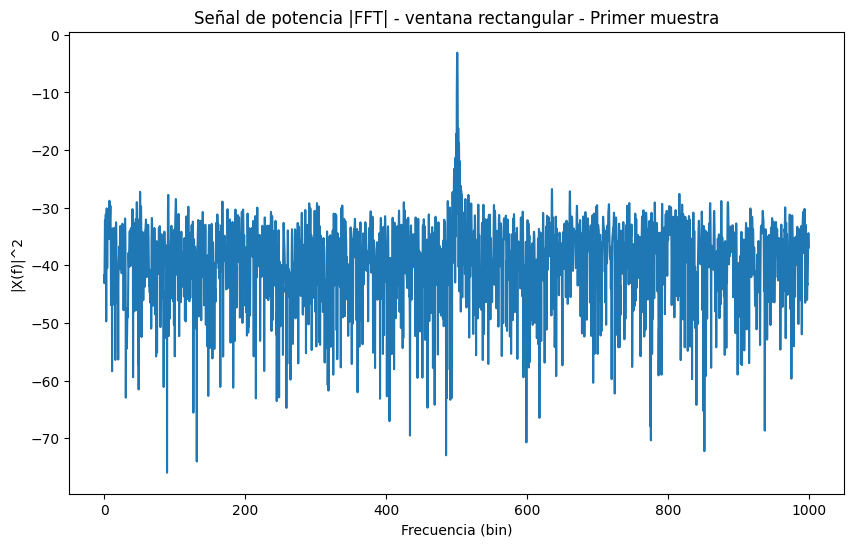

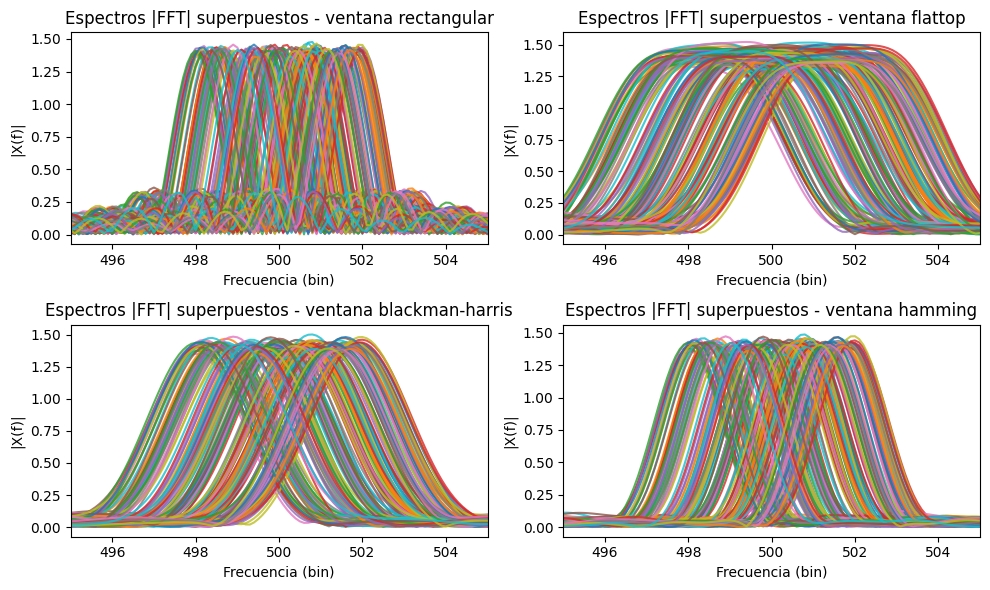

In [233]:
##### Check de primer muestra
PXX = xx_fft_abs["rectangular"][:,0]**2
plt.figure(figsize=(10,6))
plt.plot(ff[:N_FFT//2], 10*np.log10(PXX)[:N_FFT//2])
plt.title("Señal de potencia |FFT| - ventana rectangular - Primer muestra")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|^2")
plt.show()


##### Gráfico de espectros superpuestos
plt.figure(figsize=(10,6))
for key in xx_fft_abs.keys():
    plt.subplot(2,2,windows.index(key)+1)
    for i in range(xx_fft_abs[key].shape[1]):
        plt.plot(ff[:N_FFT//2], 2*xx_fft_abs[key][:, i][:N_FFT//2], alpha=0.8)
    plt.xlim(f0*0.99, f0*1.01)
    plt.title(f"Espectros |FFT| superpuestos - ventana {key}")
    plt.xlabel("Frecuencia (bin)")
    plt.ylabel("|X(f)|")
    plt.tight_layout()
plt.show()


Igual que en la prueba anterior, se realizan 2 gráficos.

En el primero se obtiene la PSD de la primer muestra a simples efectos demostrativos. De nuevo, una delta en f0 con su piso de ruido correspondiente.

En el segundo gráfico se observa la superposición de todas las muestras tomadas utilizando cada una de las ventanas. Se observa que las mismas están muchísimo más suavizadas que en el caso anterior. Esto debido al zero-padding que nos da una mejor resolución de los espectros.

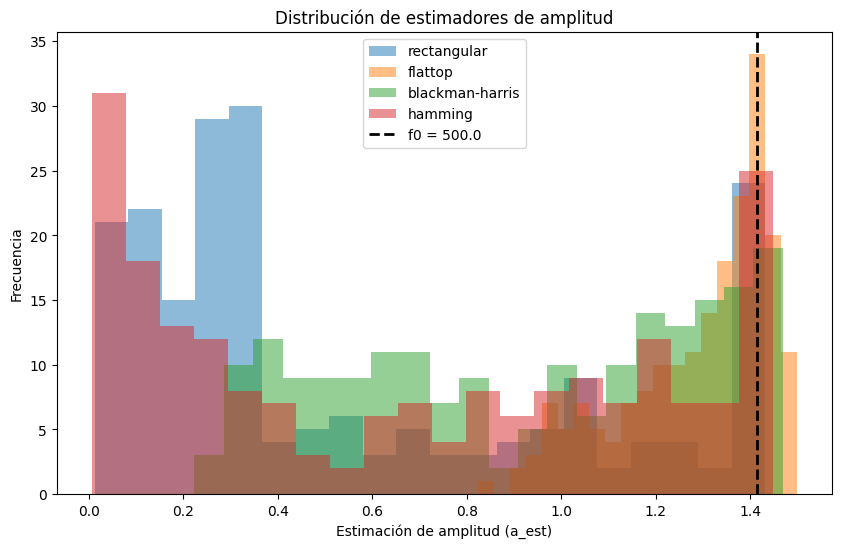

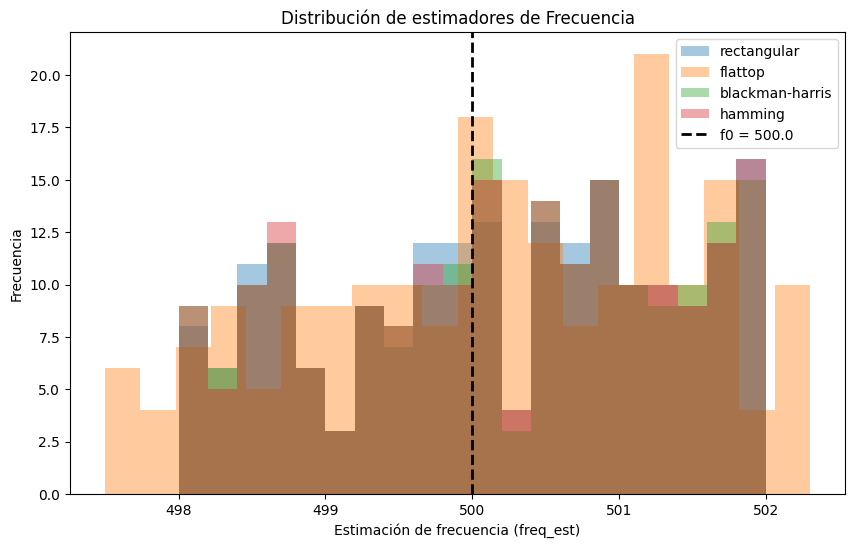

In [234]:
##### Histograma de estimación de energía
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .5

for key in a_est.keys():
    ax.hist(a_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(vmax, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de amplitud (a_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de amplitud")
ax.legend()
plt.show()

##### Histograma de estimación de frecuencia
fig, ax = plt.subplots(figsize=(10,6))
bins = 20 
alpha = .4
for key in freq_est.keys():
    ax.hist(freq_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(f0, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de frecuencia (freq_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de Frecuencia")
ax.legend()
plt.show()

Se realiza el histograma de las 2 estimaciones realizadas. 

Se observa que el histograma de energía apenas sufrió cambios. La energía medida con o sin zero-padding no se alteraba mucho y se solucionaba bastante bien con el uso de ventanas.

Muy por el contrario, en el histograma de frecuencia se observa que ahora aparecen muchos más valores posibles que antes. Esto tiene lógica, al mejorar la resolución ahora el máximo se puede encontrar en un bin de una frecuencia que antes ni siquiera existía.

Se observa que el histograma de frecuencia sí posee una forma similar a la señal uniforme original, centrada en f0 con rangos de +-2. Se observa una mayor predilección por frecuencias mayores (502) pero puede deberse a simple suerte al elegir los datos.

In [235]:
##### Cálculo de sesgo
sesgo_a_zp = {}
sesgo_freq_zp = {}
var_a_zp = {}
var_freq_zp = {}

for key in a_est.keys():
    sesgo_a_zp[key] = np.mean(vmax - a_est[key])
    var_a_zp[key] = np.var(vmax - a_est[key])
    sesgo_freq_zp[key] = np.mean(freq - freq_est[key])
    var_freq_zp[key] = np.var(freq - freq_est[key])

In [236]:
print("Valores originales:")
print("="*80)
print(f"{'Ventana':<15} |{'Sesgo a':>15} {'Varianza a':>15} {'Sesgo freq':>15} {'Varianza freq':>15}")
print("="*80)
for key in sesgo_a.keys():
    print(
        f"{key:<15} |"
        f"{sesgo_a[key]:>15.3g} "
        f"{var_a[key]:>15.3g} "
        f"{sesgo_freq[key]:>15.3g} "
        f"{var_freq[key]:>15.3g} "
    )
print("="*80 + "\n\n")

print("Valores con zero-padding:")
print("="*80)
print(f"{'Ventana':<15} |{'Sesgo a':>15} {'Varianza a':>15} {'Sesgo freq':>15} {'Varianza freq':>15}")
print("="*80)
for key in sesgo_a_zp.keys():
    print(
        f"{key:<15} |"
        f"{sesgo_a_zp[key]:>15.3g} "
        f"{var_a_zp[key]:>15.3g} "
        f"{sesgo_freq_zp[key]:>15.3g} "
        f"{var_freq_zp[key]:>15.3g} "
    )
print("="*80 + "\n\n")

Valores originales:
Ventana         |        Sesgo a      Varianza a      Sesgo freq   Varianza freq
rectangular     |          0.911           0.219        -0.00876          0.0776 
flattop         |          0.134          0.0264         -0.0338           0.138 
blackman-harris |          0.519           0.147         0.00124           0.078 
hamming         |          0.788           0.257        -0.00376          0.0776 


Valores con zero-padding:
Ventana         |        Sesgo a      Varianza a      Sesgo freq   Varianza freq
rectangular     |          0.877           0.212        -0.00245        0.000983 
flattop         |          0.123          0.0238         -0.0125           0.196 
blackman-harris |          0.487           0.144        -0.00245         0.00117 
hamming         |          0.746           0.256        -0.00245         0.00101 




Se observan meoras en la mayoría de sesgos y varianzas utilizando zero-padding frente a no utilizarlo. El único valor que no fue mejorado con el zero-padding es la varianza de frecuenca utilizando la ventana flattop; ventana que ya de por sí empeoraba la medición con respecto a una señal sin ventana.

Todas las mediciones dieron mejor ya que, al aumentar la resolución, nuestra estimación puede tomar valores de frecuencia que antes no existian y donde pudo haberse encontrado el máximo. Esto provoca que, en general, el estimador le pegue más seguido al valor correcto o a uno más cercano que antes.

# CONCLUSION:

Se concluye que, para relizar una medición de energía o de algún valor puntual, la ventana flattop es la ideal. Para medir la frecuencia en la que se encuentre una señal, la ventana hamming o directamente no utilizar ninguna ventana dieron los mejores resultados (debido al ensanchamiento de los lóbulos principales dado por las ventanas).

Se demostró en base a ejemplos que el zero-padding nos permite obtener mejores mediciones.

Es importante resaltar que estos resultados se obtuvieron con 2 estimadores propuestos: fft[f0] y argmax(fft) para energía y frecuencia respectivamente. Estos estiadores pueden o no verse afectados por el ruido y existen otras formas de estimar los mismos valores. Conocer nuestra señal de entrada nos permite utilizar realizar algunas suposiciones como por el valor de f0. Si la señal no fuese conocida se debería obtener primero f0 con una inspección general y luego estimar energía con dicho valor, o estimar energía de una forma completamente distinta.

Se concluye entonces que las ventanas y el zero-padding mejoran las mediciones y que estas técnicas deben usarse a sabiendas de lo que se desea medir. Tener conocimiento previo de la función también es una gran ventaja para estimar sus parámetros.